In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("/content/titanic.csv")

print(df.head(10))

print("\nShape:", df.shape)

print("\nInfo:")
df.info()

print("\nDescribe:")
print(df.describe())

   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   
5          897         0       3   
6          898         1       3   
7          899         0       2   
8          900         1       3   
9          901         0       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   
5                    Svensson, Mr. Johan Cervin    male  14.0      0      0   
6                          Connolly, Miss. Kate  f

In [7]:
print("\nMissing Values:\n", df.isnull().sum())

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("\nAfter Cleaning:\n", df.isnull().sum())


Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

After Cleaning:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [8]:
print("Age - Mean:", df['Age'].mean())
print("Age - Median:", df['Age'].median())
print("Age - Std Dev:", df['Age'].std())

print("\nFare - Mean:", df['Fare'].mean())
print("Fare - Median:", df['Fare'].median())
print("Fare - Std Dev:", df['Fare'].std())

print("\nSurvival Counts:\n", df['Survived'].value_counts())

Age - Mean: 29.599282296650717
Age - Median: 27.0
Age - Std Dev: 12.703769846333287

Fare - Mean: 35.627188489208635
Fare - Median: 14.4542
Fare - Std Dev: 55.90757617997383

Survival Counts:
 Survived
0    266
1    152
Name: count, dtype: int64



Gender Survival Rate:
 Sex
female    1.0
male      0.0
Name: Survived, dtype: float64


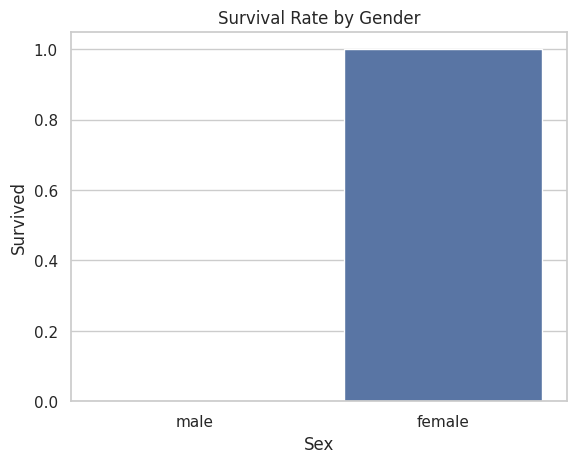

In [9]:
gender_survival = df.groupby('Sex')['Survived'].mean()
print("\nGender Survival Rate:\n", gender_survival)

# Bar plot
sns.barplot(x='Sex', y='Survived', data=df)
plt.title("Survival Rate by Gender")
plt.show()


Class Survival Rate:
 Pclass
1    0.467290
2    0.322581
3    0.330275
Name: Survived, dtype: float64


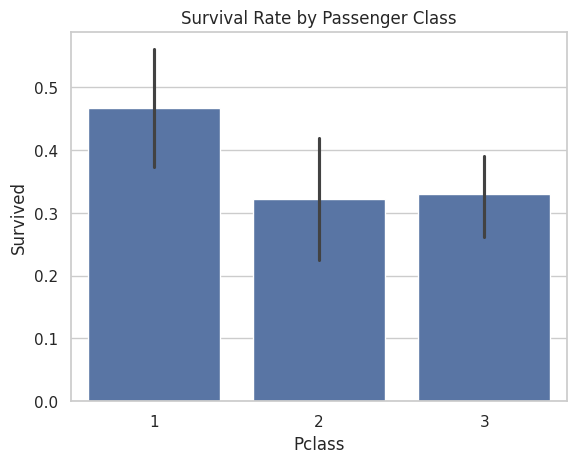

In [10]:
# Survival rate by class
class_survival = df.groupby('Pclass')['Survived'].mean()
print("\nClass Survival Rate:\n", class_survival)

# Bar plot
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()

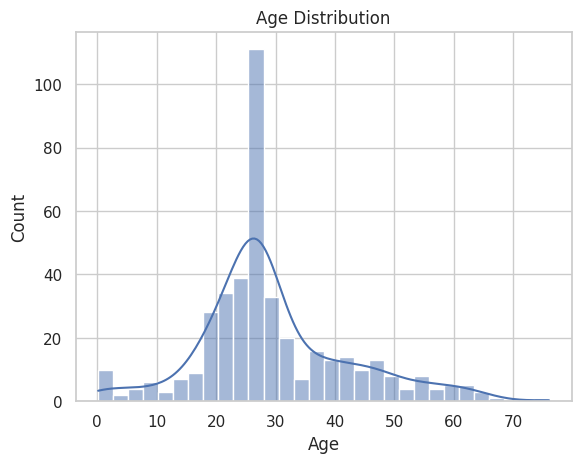

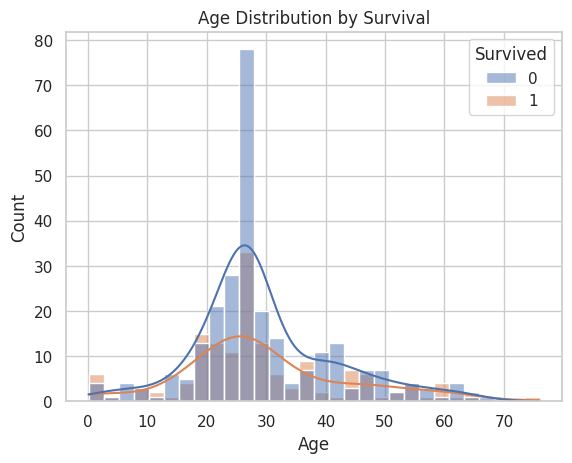

In [11]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True)
plt.title("Age Distribution by Survival")
plt.show()

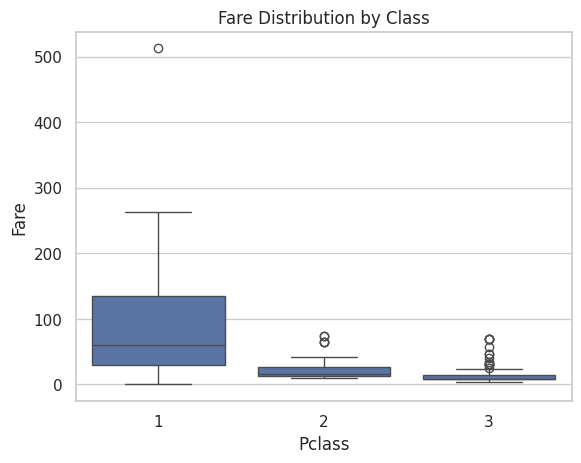

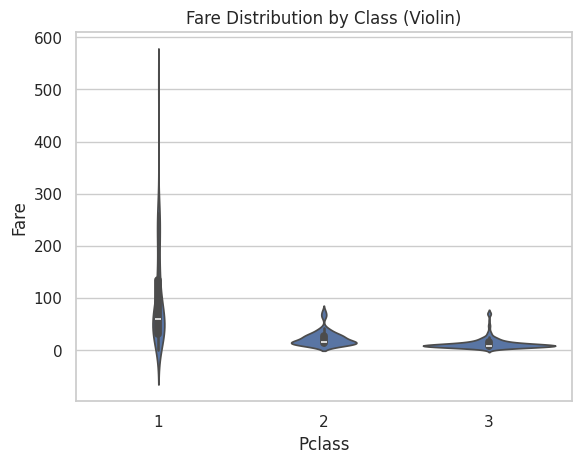

In [12]:
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title("Fare Distribution by Class")
plt.show()

sns.violinplot(x='Pclass', y='Fare', data=df)
plt.title("Fare Distribution by Class (Violin)")
plt.show()


Correlation Matrix:
             Age      Fare     SibSp     Parch
Age    1.000000  0.347105 -0.071197 -0.043731
Fare   0.347105  1.000000  0.171539  0.230046
SibSp -0.071197  0.171539  1.000000  0.306895
Parch -0.043731  0.230046  0.306895  1.000000


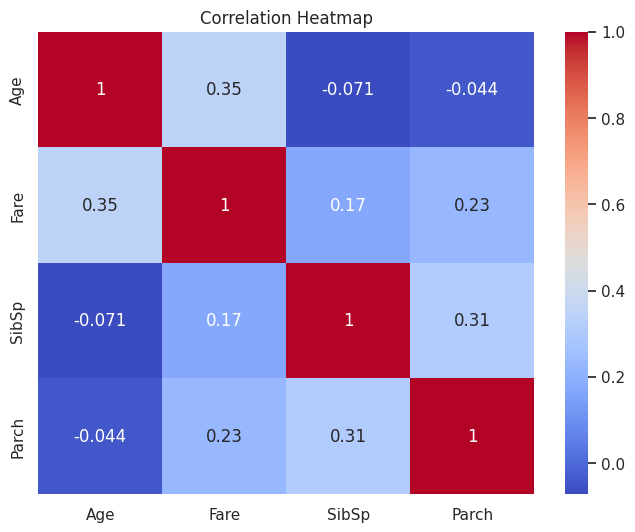

In [13]:
corr = df[['Age', 'Fare', 'SibSp', 'Parch']].corr()
print("\nCorrelation Matrix:\n", corr)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

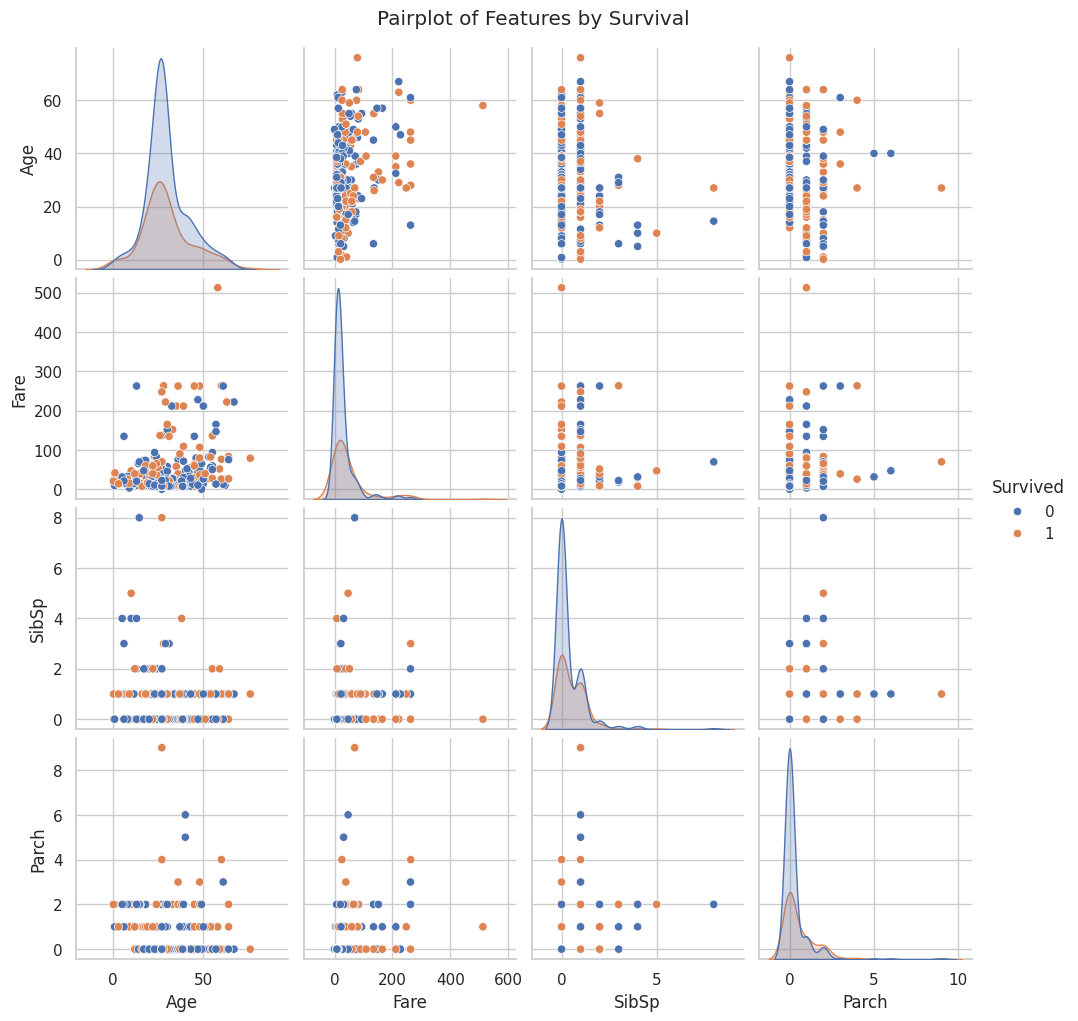

In [14]:
sns.pairplot(df[['Age', 'Fare', 'SibSp', 'Parch', 'Survived']], hue='Survived')
plt.suptitle("Pairplot of Features by Survival", y=1.02)
plt.show()

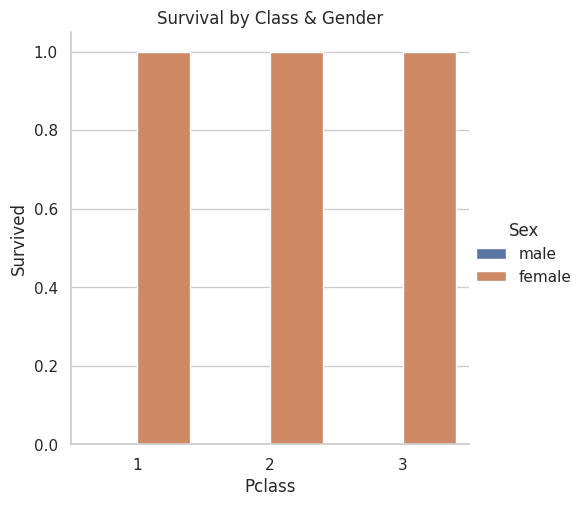

In [15]:
sns.catplot(
    x='Pclass', y='Survived', hue='Sex', kind='bar', data=df
)
plt.title("Survival by Class & Gender")
plt.show()

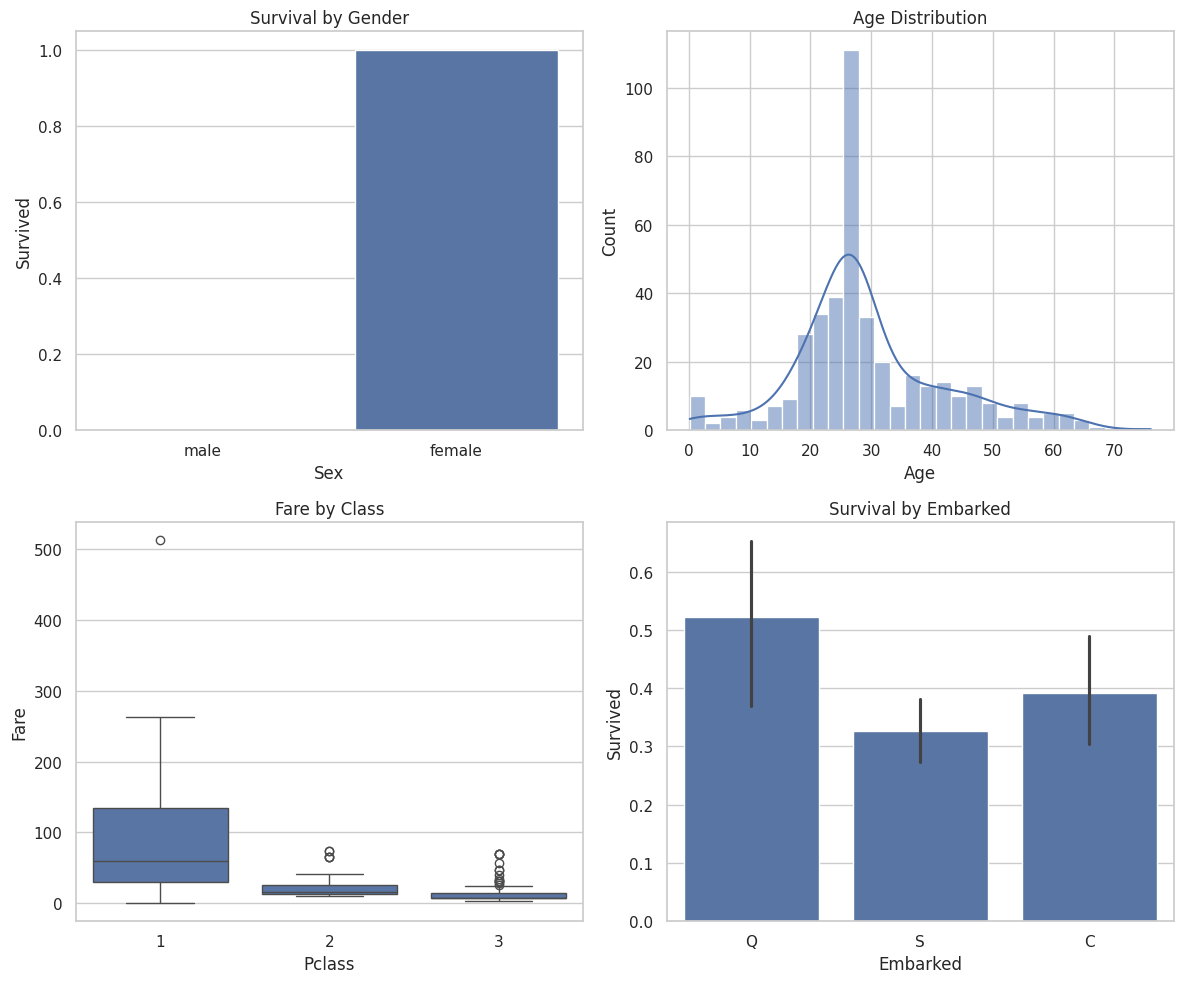

In [16]:
plt.figure(figsize=(12,10))

# 1. Survival by Gender
plt.subplot(2,2,1)
sns.barplot(x='Sex', y='Survived', data=df)
plt.title("Survival by Gender")

# 2. Age Distribution
plt.subplot(2,2,2)
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")

# 3. Fare by Class
plt.subplot(2,2,3)
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title("Fare by Class")

# 4. Survival by Embarked
plt.subplot(2,2,4)
sns.barplot(x='Embarked', y='Survived', data=df)
plt.title("Survival by Embarked")

plt.tight_layout()
plt.show()